In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
#import xesmf as xe



In [ ]:
#Hindcast Data: https://cds.climate.copernicus.eu/datasets/seasonal-monthly-single-levels?tab=download
#Note fixed hindcast period here: https://confluence.ecmwf.int/display/CKB/Description+of+the+C3S+seasonal+multi-system
#ERA5 Monthly Average (1981-2016): https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download

In [2]:
hindcast = xr.open_dataset("/home/emily_zuetell/projects/poreallas/scripts/data/s51_hcm.nc")

In [3]:
hindcast

<xarray.Dataset> Size: 2MB
Dimensions:                  (forecast_reference_time: 1, forecastMonth: 6,
                              latitude: 180, longitude: 360)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * forecastMonth            (forecastMonth) int64 48B 1 2 3 4 5 6
  * latitude                 (latitude) float64 1kB 89.5 88.5 ... -88.5 -89.5
  * longitude                (longitude) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
    number                   int64 8B ...
Data variables:
    t2m                      (forecast_reference_time, forecastMonth, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-01T21:51 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
def adjust_month_leadtime(ds, lead):
    ds = ds.copy()
    ref = ds.month.values   
    lead = lead-1            

    actual = np.array([
        (((ref_t - lead-1)%12) +1)
        for ref_t in ref
    ])

    ds = ds.assign_coords(
        month=(["month"], actual)
    )
    return ds

def subtract_clim(group):
    fm = int(group.forecastMonth.values[0])
    clim_adjusted = adjust_month_leadtime(climatology, fm)
    return group - clim_adjusted


In [ ]:
era5_mortality_baseline = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/tas_ERA5.zarr')
era5_mortality_baseline = era5_mortality_baseline['tas'].sel(time = slice("2016-01-01", "2025-12-31")).groupby("time.month").mean()

In [10]:
ds_hindcast = xr.open_dataset('./data/s51_hcm_allmonths.nc')
da_hindcast = ds_hindcast['t2m'].assign_coords(forecast_reference_time=ds_hindcast.forecast_reference_time.dt.month).rename({'forecast_reference_time':'month'})

ds_era5_hcperiod = xr.open_dataset("./data/era5_monthly_1981_2016.nc")
da_era5 = ds_era5_hcperiod['t2m'].sel(valid_time = slice("1981-01-01", "2016-12-01")).groupby("valid_time.month").mean()

#regridder = xe.Regridder(da_era5, da_hindcast, "bilinear")
#da_era5_regridded = regridder(da_era5)
da_era5_regridded = da_era5.interp_like(da_hindcast, method="linear")


In [12]:
climatology = da_era5_regridded
bias_adj = da_hindcast.groupby("forecastMonth").map(subtract_clim)

In [13]:
bias_ez = da_hindcast.sel(month = 5, forecastMonth = 6)-da_era5_regridded.sel(month = 10)
bias_bm = xr.open_dataset("/home/emily_zuetell/projects/poreallas/scripts/data/bias-20260615.nc")

In [ ]:
#bias_adj.to_zarr("bias_adjustment_ERA5_19932016.zarr", zarr_format=2)

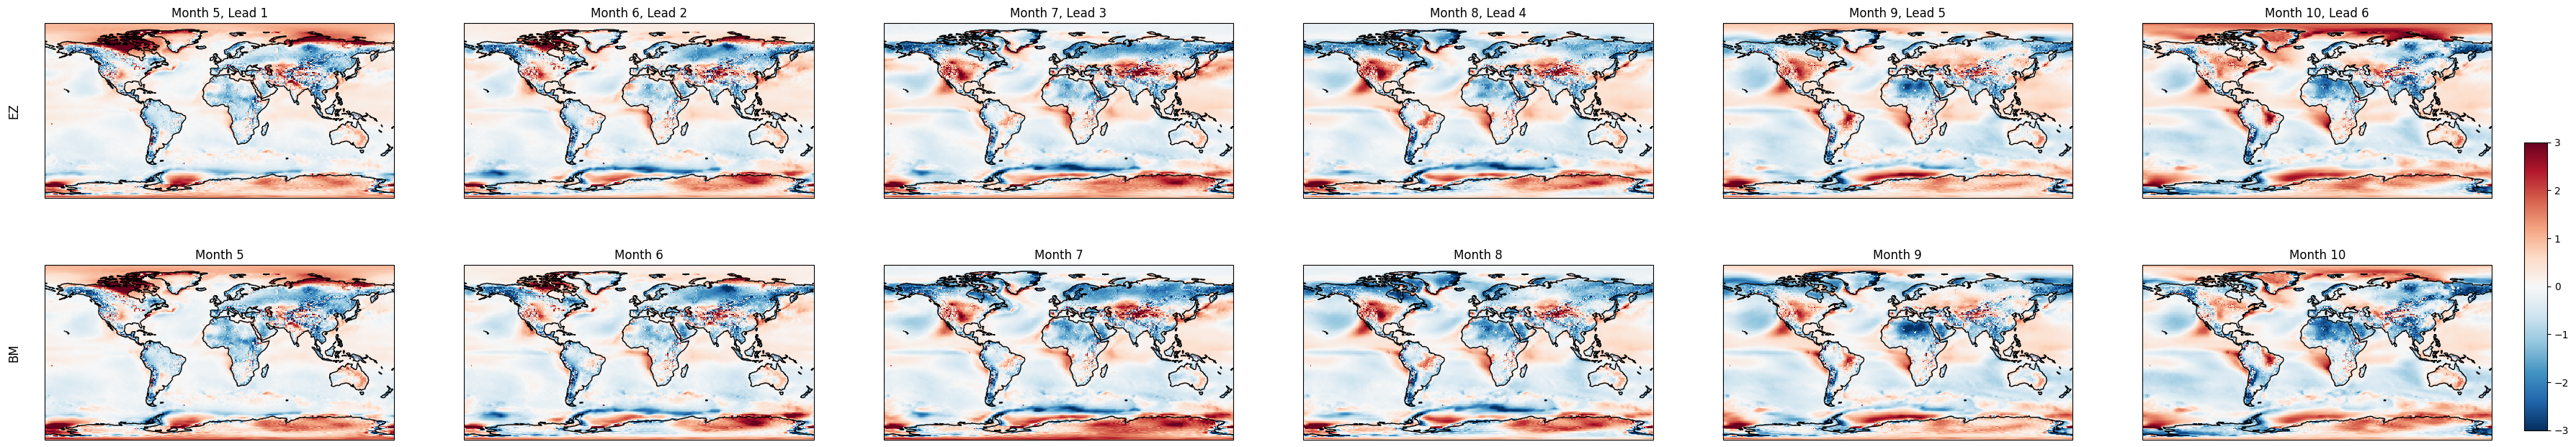

In [139]:
ds2 = bias_bm['bias']

fig, axes = plt.subplots(
    2, n,
    figsize=(5 * 1.5*n, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(right=0.88)

vmin = -3
vmax = 3

for col, (month, lead) in enumerate(pairs):
    bias_ez = da_hindcast.sel(month = (month-lead+1), forecastMonth = lead)-da_era5_regridded.sel(month = month)
    im = bias_ez.plot(
        ax=axes[0, col],
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=vmin, vmax=vmax, cmap = 'RdBu_r',
    )
    axes[0, col].coastlines()
    axes[0, col].set_title(f"Month {month}, Lead {lead}")

    ds2.sel(month=month).plot(
        ax=axes[1, col],
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=vmin, vmax=vmax, cmap = 'RdBu_r',
    )
    axes[1, col].coastlines()
    axes[1, col].set_title(f"Month {month}")

cbar_ax = fig.add_axes([0.89, 0.15, 0.007, 0.5])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)

row_labels = ["EZ", "BM"]

for ax, label in zip(axes[:, 0], row_labels):
    ax.text(-0.07, 0.5, label, transform=ax.transAxes,
            ha="right", va="center", rotation=90, fontsize=12)
    
plt.show()

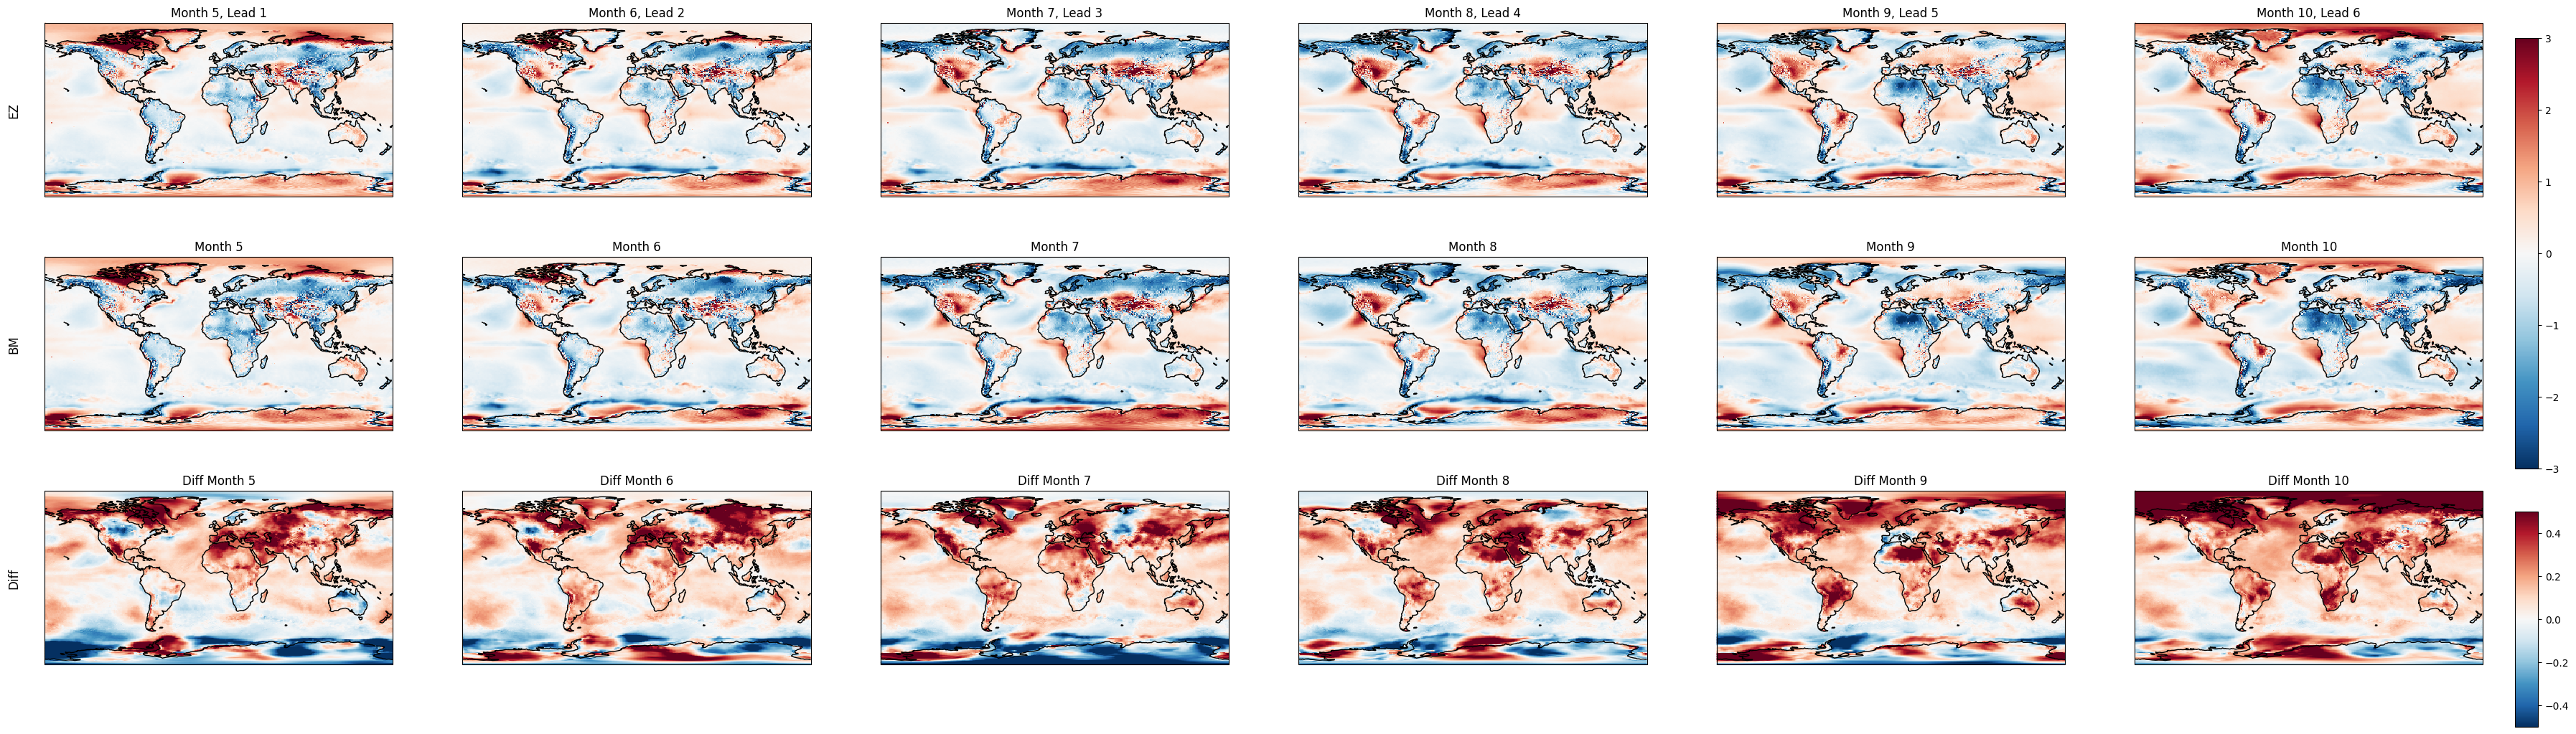

In [144]:
pairs = [
    (5, 1),
    (6, 2),
    (7, 3),
    (8, 4),
    (9, 5),
    (10, 6),
]
n = len(pairs)

ds2 = bias_bm['bias']

fig, axes = plt.subplots(
    3, n,
    figsize=(5 * 1.5*n, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(right=0.88)

vmin, vmax = -3, 3
diff_vmin, diff_vmax = -.5, .5  # adjust as needed

for col, (month, lead) in enumerate(pairs):
    bias_ez = da_hindcast.sel(month=(month-lead+1), forecastMonth=lead) - da_era5_regridded.sel(month=month)
    bias_bm = ds2.sel(month=month)

    im = bias_ez.plot(
        ax=axes[0, col], transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=vmin, vmax=vmax, cmap='RdBu_r',
    )
    axes[0, col].coastlines()
    axes[0, col].set_title(f"Month {month}, Lead {lead}")

    bias_bm.plot(
        ax=axes[1, col], transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=vmin, vmax=vmax, cmap='RdBu_r',
    )
    axes[1, col].coastlines()
    axes[1, col].set_title(f"Month {month}")

    diff = bias_ez - bias_bm
    im_diff = diff.plot(
        ax=axes[2, col], transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=diff_vmin, vmax=diff_vmax, cmap='RdBu_r',
    )
    axes[2, col].coastlines()
    axes[2, col].set_title(f"Diff Month {month}")

cbar_ax = fig.add_axes([0.89, 0.35, 0.007, 0.5])
fig.colorbar(im, cax=cbar_ax)

cbar_diff_ax = fig.add_axes([0.89, 0.05, 0.007, 0.25])
fig.colorbar(im_diff, cax=cbar_diff_ax)

row_labels = ["EZ", "BM", "Diff"]
for ax, label in zip(axes[:, 0], row_labels):
    ax.text(-0.07, 0.5, label, transform=ax.transAxes,
            ha="right", va="center", rotation=90, fontsize=12)

plt.show()

In [5]:
pairs = [
    (5, 1),
    (6, 2),
    (7, 3),
    (8, 4),
    (9, 5),
    (10, 6),
]

In [14]:
ds_forecast = xr.open_zarr("./data/tas_forecast.zarr")

In [17]:
era5_mortality_baseline

<xarray.DataArray 'tas' (time: 3653, latitude: 180, longitude: 360)> Size: 947MB
dask.array<getitem, shape=(3653, 180, 360), dtype=float32, chunksize=(708, 23, 45), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 29kB 2016-01-01 2016-01-02 ... 2025-12-31
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Attributes:
    regrid_method:  bilinear
    long_name:      2 metre temperature
    short_name:     t2m
    units:          K

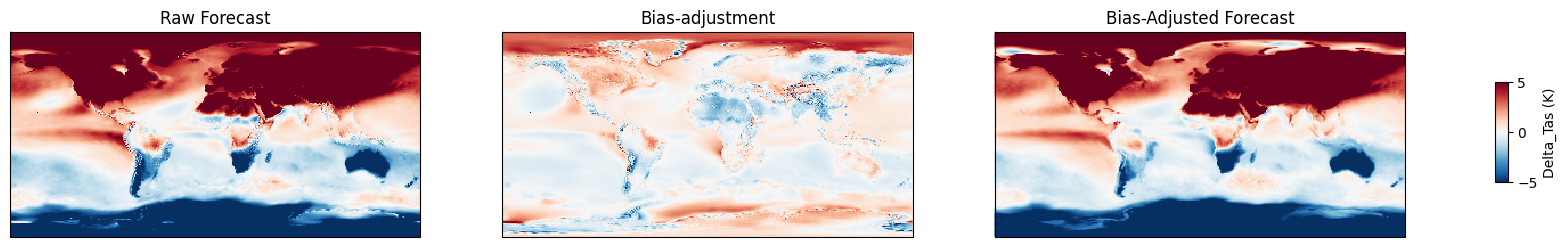

In [24]:
fig, ax = plt.subplots(
    1,3, 
    figsize=(18, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

month = 10
lead = 4
bias_adjustment = (da_hindcast.sel(month=(month-lead+1), forecastMonth=lead) - da_era5_regridded.sel(month=month))
bias_edj_fc = ds_forecast.sel(valid_time = '2026-08-20')['tas'].mean(dim = 'number').squeeze()- era5_mortality_baseline.sel(month=month)-bias_adjustment
biased_fc = ds_forecast.sel(valid_time = '2026-08-20')['tas'].mean(dim = 'number').squeeze()-era5_mortality_baseline.sel(month=month)
#biased_fc = da_hindcast.sel(month=(month-lead+1), forecastMonth=lead)
biased_fc.plot(ax = ax[0], transform=ccrs.PlateCarree(), vmin = -5, vmax = 5, cmap='RdBu_r', add_colorbar=False)
bias_adjustment.plot(ax = ax[1], transform=ccrs.PlateCarree(), vmin = -5, vmax = 5, cmap='RdBu_r', add_colorbar=False)
im = bias_edj_fc.plot(ax = ax[2], transform=ccrs.PlateCarree(), vmin = -5, vmax = 5, cmap='RdBu_r', add_colorbar=False)
ax[0].set_title("Raw Forecast")
ax[1].set_title("Bias-adjustment")
ax[2].set_title("Bias-Adjusted Forecast")
cbar_ax = fig.add_axes([0.95, 0.4, 0.007, 0.2])
fig.colorbar(im, cax=cbar_ax, label="Delta_Tas (K)")